In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Cleaned Datasets

In [2]:
#Loading Cleaned Book dataset
book_df=pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Books_Cleaned.csv")

#Loading Cleaned user dataset
user_df=pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Users_Cleaned.csv")

#Loading Cleaned rating dataset
rating_df=pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Ratings_Cleaned.csv")

## 1. Understanding the Dataset
   - Import the core datasets (Books, Users, Ratings).
   - Inspect column names, datatypes, and missing values.
   - Perform basic summary statistics.


### Inspect Column Names, Datatypes, and Missing Values

In [3]:
#inspecting Column Names, Datatypes
def col_name(df,name):
    print(f"\n{name} - Printing column names")
    print(df.info())
    
col_name(book_df,"Book Dataset")
col_name(user_df,"Users Dataset")
col_name(rating_df,"Ratings Dataset")


Book Dataset - Printing column names
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   book_id              271360 non-null  object
 1   title                271360 non-null  object
 2   author               271360 non-null  object
 3   Year-Of-Publication  271360 non-null  int64 
 4   publisher            271360 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271360 non-null  object
dtypes: int64(1), object(7)
memory usage: 16.6+ MB
None

Users Dataset - Printing column names
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277610 entries, 0 to 277609
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   277610 non-null  int64  
 1   location  277610 non-n

###  Inspecting Missing Values

In [4]:
#Inspecting missing values
def missing_values(df,name):
    print(f"\n{name} - Checking Missing values")
    print(df.isnull().sum())
    
missing_values(book_df,"Book Dataset")
missing_values(user_df,"Users Dataset")
missing_values(rating_df,"Ratings Dataset")



Book Dataset - Checking Missing values
book_id                0
title                  0
author                 0
Year-Of-Publication    0
publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

Users Dataset - Checking Missing values
user_id     0
location    0
age         0
dtype: int64

Ratings Dataset - Checking Missing values
user_id    0
book_id    0
ratings    0
dtype: int64


###  Performing Basic Summary Statistics

In [5]:
def summary(df,name):
    print(f"\n {name} - summary statistics")
    print(df.describe())

summary(book_df,"Books Dataset")
summary(user_df,"Users Dataset")
summary(rating_df,"Ratings Dataset")


 Books Dataset - summary statistics
       Year-Of-Publication
count        271360.000000
mean           1993.731983
std               8.083916
min            1806.000000
25%            1989.000000
50%            1996.000000
75%            2000.000000
max            2024.000000

 Users Dataset - summary statistics
             user_id            age
count  277610.000000  277610.000000
mean   139432.837430      33.650773
std     80494.242151      10.654276
min         1.000000       5.000000
25%     69718.250000      29.000000
50%    139426.500000      32.000000
75%    209137.750000      35.000000
max    278858.000000     100.000000

 Ratings Dataset - summary statistics
             user_id        ratings
count  433671.000000  433671.000000
mean   135458.743451       7.601066
std     80678.385078       1.843798
min         8.000000       1.000000
25%     66619.000000       7.000000
50%    133184.000000       8.000000
75%    205735.000000       9.000000
max    278854.000000      10.000

## 2. Analyze Rating Patterns
   - Plot distribution of ratings (e.g., count of each rating from 1–10).
   - Calculate average rating per user and per book.
   - Identify number of users who rated more than N books (try N = 10, 20, 50).
   - Identify books with the highest and lowest average ratings.


### Plot Distribution of Ratings

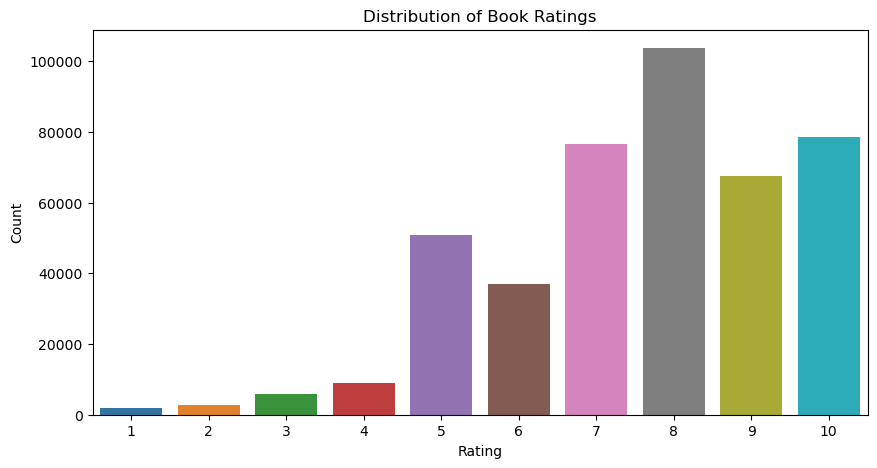

In [6]:
# Plot count of each rating
plt.figure(figsize=(10, 5))
sns.countplot(x=rating_df["ratings"])
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Calculate Average Rating per User and per Book

In [7]:
# Average rating per user
avg_rating_per_user = rating_df.groupby('user_id')['ratings'].mean().sort_values(ascending=False)
print("Average Rating per User:\n", avg_rating_per_user.head())

# Average rating per book
avg_rating_per_book = rating_df.groupby('book_id')['ratings'].mean().sort_values(ascending=False)
print("Average Rating per Book:\n", avg_rating_per_book.head())


Average Rating per User:
 user_id
27839     10.0
31070     10.0
119148    10.0
119108    10.0
119105    10.0
Name: ratings, dtype: float64
Average Rating per Book:
 book_id
8447309703    10.0
1559634634    10.0
1559702028    10.0
8472452786    10.0
1559700904    10.0
Name: ratings, dtype: float64


### Number of Users Who Rated More Than N Books

In [8]:
# Ratings count per user
user_rating_counts = rating_df['user_id'].value_counts()

# Users who rated more than N books
for N in [10, 20, 50]:
    count = (user_rating_counts > N).sum()
    print(f"Users who rated more than {N} books: {count}")


Users who rated more than 10 books: 6655
Users who rated more than 20 books: 3521
Users who rated more than 50 books: 1295


### Books with the Highest and Lowest Average Ratings

In [9]:
# Count number of ratings per book
book_rating_counts = rating_df.groupby('book_id').size()

# Filter books with at least 10 ratings
popular_books = book_rating_counts[book_rating_counts >= 10].index

# Filter ratings for popular books
filtered_ratings = rating_df[rating_df['book_id'].isin(popular_books)]

# 4. Compute average ratings for these books
average_ratings = filtered_ratings.groupby('book_id')['ratings'].mean()


In [10]:
#Top 5 Highest Rated Books
high_books = average_ratings.sort_values(ascending=False).head()
for book_id, rating in high_books.items():
    print(f"Book ID: {book_id}, Average Rating: {rating:.2f}")


Book ID: 1888054557, Average Rating: 10.00
Book ID: 0836213319, Average Rating: 9.92
Book ID: 0439425220, Average Rating: 9.87
Book ID: 0394823370, Average Rating: 9.80
Book ID: 0312992416, Average Rating: 9.80


In [11]:
# 5 low Rated Books
low_books = average_ratings.sort_values().head()
for book_id, rating in low_books.items():
    print(f"Book ID: {book_id}, Average Rating: {rating:.2f}")


Book ID: 0971880107, Average Rating: 4.39
Book ID: 3442452031, Average Rating: 4.90
Book ID: 1401088945, Average Rating: 5.00
Book ID: 0679463321, Average Rating: 5.07
Book ID: 0349111863, Average Rating: 5.08


## 3. Visualize User & Book Activity


### Plots
 - Number of ratings per user (long tail distribution).
 -  Number of ratings per book.
  - Heatmap showing user-book interactions (sparse matrix view)

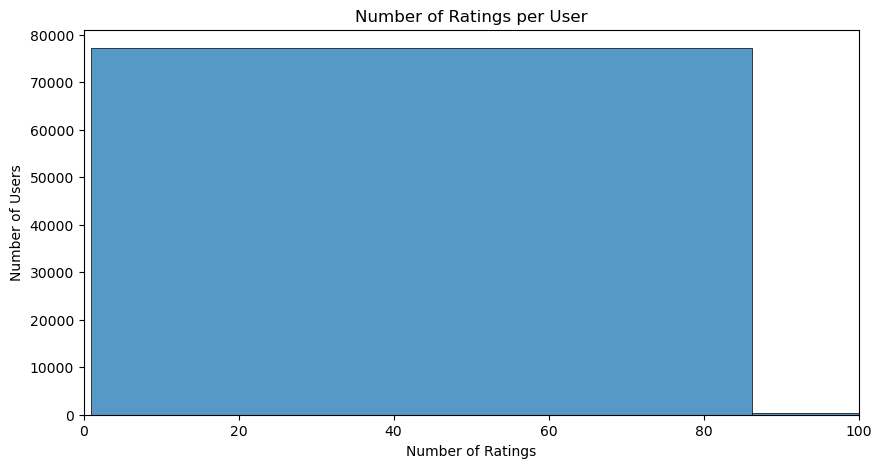

In [12]:
# Number of Ratings per User (Long Tail Distribution)
user_rating_counts = rating_df['user_id'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(user_rating_counts, bins=100, kde=False)
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.xlim(0, 100)  # zoom into the long tail
plt.show()


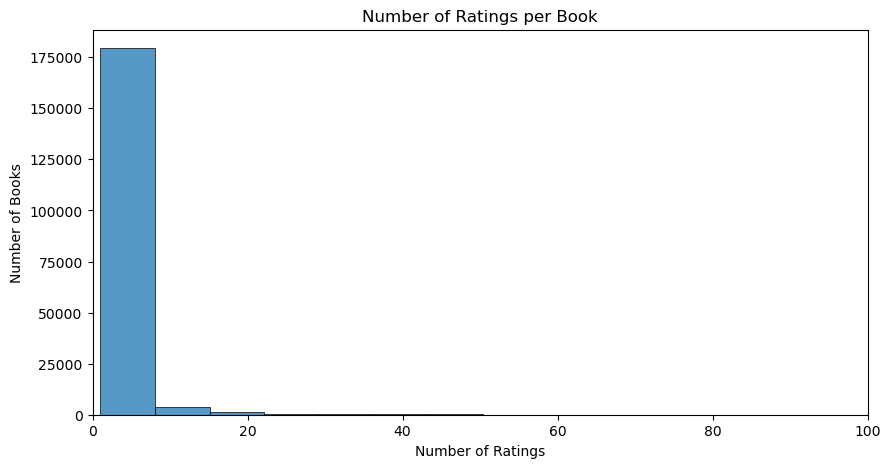

In [13]:
# Number of ratings per book

book_rating_counts = rating_df['book_id'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(book_rating_counts, bins=100, kde=False)
plt.title('Number of Ratings per Book')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Books')
plt.xlim(0, 100)  
plt.show()

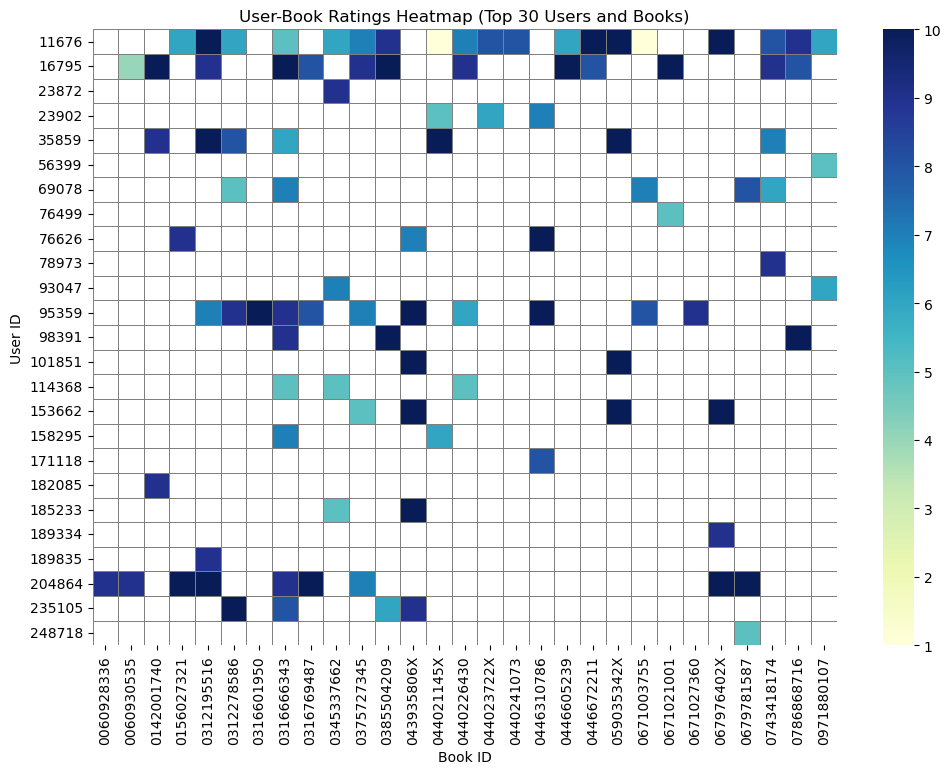

In [14]:
# Heatmap showing user-book interactions (sparse matrix view)

top_users = rating_df['user_id'].value_counts().head(30).index
top_books = rating_df['book_id'].value_counts().head(30).index

# Filter ratings to include only selected users and books
sample_data = rating_df[
    (rating_df['user_id'].isin(top_users)) &
    (rating_df['book_id'].isin(top_books))
]

# Create user-book interaction matrix
interaction = sample_data.pivot_table(
    index='user_id',
    columns='book_id',
    values='ratings'
)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(interaction, cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('User-Book Ratings Heatmap (Top 30 Users and Books)')
plt.xlabel('Book ID')
plt.ylabel('User ID')
plt.show()


## 4. Identify Top Users and Books
  - Top 10 most active users (users who rated the most books).
  - Top 10 most rated books.
  - Top 10 highest rated books with at least 50 ratings (filter for significance).

### Top 10 Most Active Users (Users who rated the most books)

In [15]:
top_users = rating_df.groupby('user_id').size().sort_values(ascending=False).head(10)
print("Top 10 Most Active Users:")
print(top_users)

Top 10 Most Active Users:
user_id
11676     8524
98391     5802
153662    1969
189835    1906
23902     1395
76499     1036
171118    1035
235105    1023
16795      968
248718     948
dtype: int64


### Top 10 most rated books.

In [16]:
top_books = rating_df.groupby('book_id').size().sort_values(ascending=False).head(10)
print("Top 10 Most rated books:")
print(top_books)

Top 10 Most rated books:
book_id
0316666343    707
0971880107    581
0385504209    487
0312195516    383
0679781587    333
0060928336    320
059035342X    313
0142001740    307
0446672211    295
044023722X    281
dtype: int64


### Top 10 highest rated books with at least 50 ratings 

In [17]:
book_ratings = rating_df.groupby('book_id')['ratings'].agg(['mean', 'count'])

# books with at least 50 ratings
popular_books = book_ratings[book_ratings['count'] >= 50]

# Sort by mean rating to get the highest-rated books
top_rated_books = popular_books.sort_values(by='mean', ascending=False).head(10)
print("\nTop 10 Highest Rated Books (with at least 50 ratings):")
print(top_rated_books)


Top 10 Highest Rated Books (with at least 50 ratings):
                mean  count
book_id                    
0345339738  9.402597     77
0439139597  9.262774    137
043936213X  9.207547     53
0345339711  9.120482     83
0439136369  9.082707    133
0064400557  9.073529     68
0439136350  9.035461    141
043935806X  9.033981    206
0590353403  8.983193    119
0156528207  8.980392     51


## 5. Understand Data Sparsity
   - Compute user-book interaction matrix.
   - Calculate sparsity as:
   - Sparsity = 1 - (Number of Ratings / Total Possible Ratings)
   - Briefly interpret what this means for collaborative filtering.

### Compute user-book interaction matrix.

In [18]:
# Aggregate to remove duplicates
aggregated = rating_df.groupby(['user_id', 'book_id'])['ratings'].mean().reset_index()

# Filter to reduce size for safe pivot
top_users = aggregated['user_id'].value_counts().head(50).index
top_books = aggregated['book_id'].value_counts().head(50).index
filtered = aggregated[(aggregated['user_id'].isin(top_users)) & (aggregated['book_id'].isin(top_books))]

# Create interaction matrix
interaction_matrix = filtered.pivot(index='user_id', columns='book_id', values='ratings')


In [19]:
#Sparsity calculation
num_users = interaction_matrix.shape[0]
num_books = interaction_matrix.shape[1]
num_ratings = filtered.shape[0]
total_possible = num_users * num_books
sparsity = 1 - (num_ratings / total_possible)

In [20]:
#results
print(f"Total users in matrix: {num_users}")
print(f"Total books in matrix: {num_books}")
print(f"Actual ratings: {num_ratings}")
print(f"Possible ratings (user x book): {total_possible}")
print(f" Sparsity of the matrix: {sparsity:.4f}")

Total users in matrix: 44
Total books in matrix: 50
Actual ratings: 235
Possible ratings (user x book): 2200
 Sparsity of the matrix: 0.8932


In [21]:
#Interpretation
if sparsity > 0.9:
    print("\nHigh sparsity means most user-book combinations are missing.")
    print("\nCollaborative filtering models may have difficulty making accurate recommendations.")
else:
    print("\nMatrix is relatively dense. Collaborative filtering can work effectively.")


Matrix is relatively dense. Collaborative filtering can work effectively.
